## Configuration 

In [1]:
from neo4j import GraphDatabase
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import time

In [2]:
URI = "bolt://localhost:7687"

driver = GraphDatabase.driver(
    URI,
    auth=("neo4j", "password")
)

## Load the friendship graph

In [3]:
def load_graph(driver):

    query = """
    MATCH (s1:Student)-[:EST_AMI_DE]->(s2:Student)
    RETURN s1.id AS source,
           s2.id AS target
    """

    G = nx.Graph()

    with driver.session() as session:

        result = session.run(query)

        for record in result:

            G.add_edge(
                record["source"],
                record["target"]
            )

    return G

In [4]:
G = load_graph(driver)

print(G.number_of_nodes())
print(G.number_of_edges())

1500
7465


## Common Neighbors

### implementation from zero

In [ ]:

def common_neighbors_score(G, u, v):

    return len(
        set(G.neighbors(u))
        &
        set(G.neighbors(v))
    )

In [6]:
recommendations = []

for u in G.nodes():

    for v in G.nodes():

        if u >= v:
            continue

        if G.has_edge(u, v):
            continue

        score = common_neighbors_score(G, u, v)

        if score > 0:

            recommendations.append(
                (u, v, score)
            )

In [7]:
recommendations.sort(
    key=lambda x: x[2],
    reverse=True
)

In [9]:
df = pd.DataFrame(
    recommendations,
    columns=[
        "Student1",
        "Student2",
        "Score"
    ]
)

df.head(20)

,Student1,Student2,Score
0,6,9,24
1,10,8,21
2,3,5,18
3,10,7,15
4,10,11,15
5,33,6,15
6,11,8,14
7,10,13,13
8,3,8,12
9,3,4,12


Text(0, 0.5, 'Frequency')

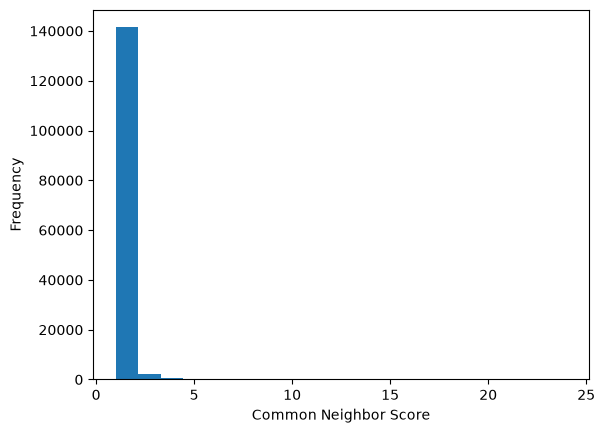

In [26]:
plt.hist(df["Score"], bins=20)

plt.xlabel("Common Neighbor Score")
plt.ylabel("Frequency")

### NetworkX Implemeantation 

In [35]:
predictions = []

for u in G.nodes():

    for v in G.nodes():

        if u >= v:
            continue

        if G.has_edge(u, v):
            continue

        score = len(list(nx.common_neighbors(G, u, v)))

        if score > 0:

            predictions.append(
                (u, v, score)
            )

In [36]:
predictions

[('2', '3', 6),
 ('2', '813', 2),
 ('2', '512', 1),
 ('2', '53', 1),
 ('2', '417', 1),
 ('2', '488', 1),
 ('2', '22', 1),
 ('2', '299', 1),
 ('2', '35', 2),
 ('2', '762', 1),
 ('2', '307', 1),
 ('2', '589', 1),
 ('2', '379', 1),
 ('2', '898', 1),
 ('2', '97', 2),
 ('2', '734', 1),
 ('2', '655', 1),
 ('2', '51', 1),
 ('2', '649', 1),
 ('2', '421', 2),
 ('2', '310', 1),
 ('2', '41', 2),
 ('2', '50', 3),
 ('2', '233', 1),
 ('2', '328', 1),
 ('2', '259', 2),
 ('2', '38', 1),
 ('2', '381', 1),
 ('2', '82', 1),
 ('2', '357', 1),
 ('2', '98', 1),
 ('2', '31', 1),
 ('2', '608', 1),
 ('2', '9', 4),
 ('2', '928', 2),
 ('2', '30', 1),
 ('2', '87', 2),
 ('2', '694', 1),
 ('2', '698', 1),
 ('2', '4', 3),
 ('2', '211', 1),
 ('2', '27', 1),
 ('2', '604', 1),
 ('2', '245', 1),
 ('2', '42', 5),
 ('2', '546', 1),
 ('2', '336', 2),
 ('2', '89', 2),
 ('2', '231', 2),
 ('2', '202', 1),
 ('2', '794', 2),
 ('2', '78', 1),
 ('2', '5', 5),
 ('2', '29', 1),
 ('2', '339', 2),
 ('2', '534', 2),
 ('2', '958', 1),


In [37]:
df_rec = pd.DataFrame(predictions,columns=[
        "Student1",
        "Student2",
        "Score"
    ])

In [38]:
df_rec.head(20)

,Student1,Student2,Score
0,2,3,6
1,2,813,2
2,2,512,1
3,2,53,1
4,2,417,1
5,2,488,1
6,2,22,1
7,2,299,1
8,2,35,2
9,2,762,1


Text(0, 0.5, 'Frequency')

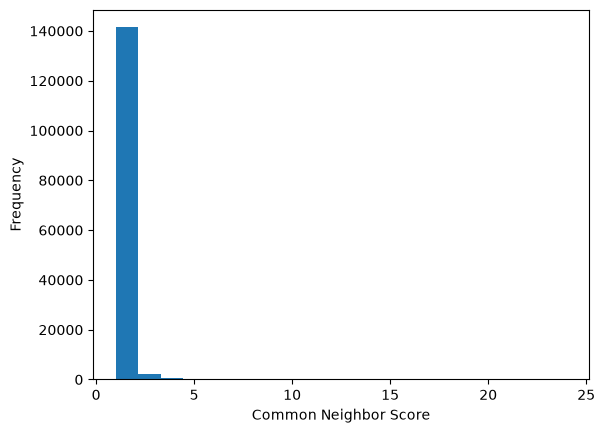

In [39]:
plt.hist(df_rec["Score"], bins=20)

plt.xlabel("Common Neighbor Score")
plt.ylabel("Frequency")

## Jaccard Similarity

### Manual implementation

In [40]:
def jaccard_similarity(G, u, v):

    neighbors_u = set(G.neighbors(u))
    neighbors_v = set(G.neighbors(v))

    intersection = neighbors_u & neighbors_v
    union = neighbors_u | neighbors_v

    if len(union) == 0:
        return 0

    return len(intersection) / len(union)

In [41]:
recommendations = []

for u in G.nodes():

    for v in G.nodes():

        if u >= v:
            continue

        if G.has_edge(u, v):
            continue

        score = jaccard_similarity(G, u, v)

        if score > 0:

            recommendations.append(
                (u, v, score)
            )

In [42]:
df = pd.DataFrame(
    recommendations,
    columns=[
        "Student1",
        "Student2",
        "Score"
    ]
)

df.head(20)

,Student1,Student2,Score
0,2,3,0.034682
1,2,813,0.035088
2,2,512,0.016949
3,2,53,0.011628
4,2,417,0.014706
5,2,488,0.015625
6,2,22,0.011236
7,2,299,0.014286
8,2,35,0.018182
9,2,762,0.016667


Text(0, 0.5, 'Frequency')

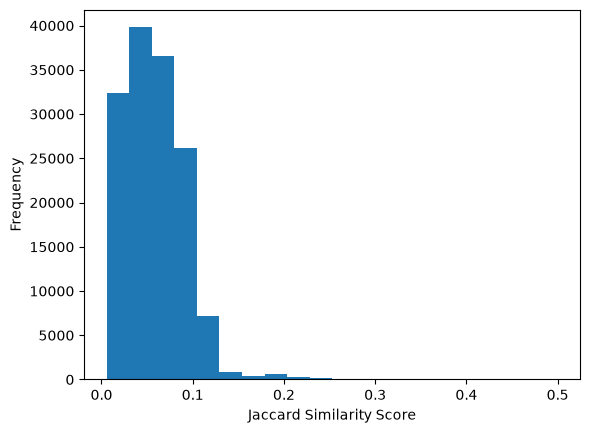

In [43]:
plt.hist(df["Score"], bins=20)

plt.xlabel("Jaccard Similarity Score")
plt.ylabel("Frequency")

### NetworkX Implementation 

In [44]:
predictions = []

for u in G.nodes():

    for v in G.nodes():

        if u >= v:
            continue

        if G.has_edge(u, v):
            continue

        score = nx.jaccard_coefficient(G, [(u, v)]).__next__()[2]

        if score > 0:

            predictions.append(
                (u, v, score)
            )

In [45]:
df_rec = pd.DataFrame(predictions,columns=[
        "Student1",
        "Student2",
        "Score"
    ])

df_rec.head(20)

,Student1,Student2,Score
0,2,3,0.034682
1,2,813,0.035088
2,2,512,0.016949
3,2,53,0.011628
4,2,417,0.014706
5,2,488,0.015625
6,2,22,0.011236
7,2,299,0.014286
8,2,35,0.018182
9,2,762,0.016667


Text(0, 0.5, 'Frequency')

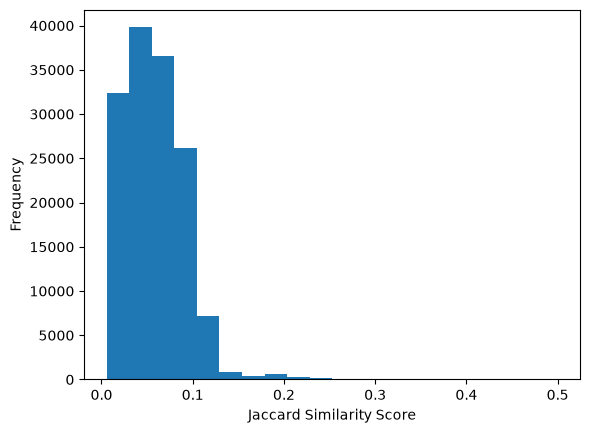

In [46]:
plt.hist(df_rec["Score"], bins=20)

plt.xlabel("Jaccard Similarity Score")
plt.ylabel("Frequency")